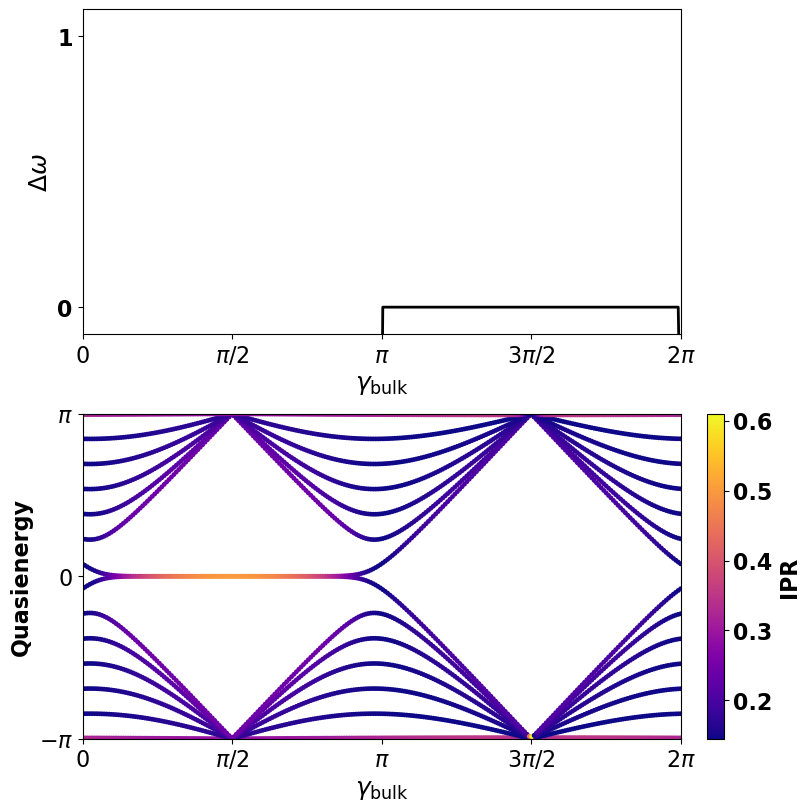

In [3]:
import numpy as np
import matplotlib.pyplot as plt

pi = np.pi


P = 7
T = 2

gamma_defect =pi +1.6

gamma_bulk_scan = np.linspace(0,2*pi,250)


coin0 = np.array([1,0],dtype=complex)
coin1 = np.array([0,1],dtype=complex)

C00 = np.outer(coin0,coin0)
C11 = np.outer(coin1,coin1)

def full_coin(theta):

    return np.array([
        [np.cos(theta),-np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ],dtype=complex)

out_left  = np.zeros((P,P))
out_right = np.zeros((P,P))

for x in range(P):

    out_left[(x-1)%P,x] = 1
    out_right[(x+1)%P,x] = 1

Splus = (
      np.kron(out_right,C00)
    + np.kron(np.eye(P),C11)
)

Sminus = (
      np.kron(out_left,C11)
    + np.kron(np.eye(P),C00)
)

#Winding Number
Nw = 1000

def winding(theta):

    total = 0

    for k in range(Nw):

        numerator = -2*np.sin(theta*T/2)

        denominator = (
            Nw*(
                2*np.cos(np.pi*k/Nw)**2*np.cos(theta*T)
                + np.cos(2*np.pi*k/Nw)
                -3
            )
        )

        if np.abs(denominator)<1e-12:
            continue

        total += numerator/denominator

    return total

omega_defect = winding(gamma_defect)

def build_coin(theta_site):

    Cfull = np.zeros((2*P,2*P),dtype=complex)

    for site in range(P):

        proj = np.zeros((P,P))
        proj[site,site]=1

        Cfull += np.kron(
            proj,
            full_coin(T*theta_site[site]/2)
        )

    return Cfull

def build_floquet(theta_site):

    Cfull = build_coin(theta_site)

    U = (
        Splus
        @ Cfull
        @ Sminus
        @ Cfull
    )

    return U


def floquet_spectrum(theta_site):

    U = build_floquet(theta_site)

    eigval,eigvec = np.linalg.eig(U)

    E = -np.angle(eigval)

    order = np.argsort(E)

    eigval = eigval[order]
    eigvec = eigvec[:,order]
    E = E[order]

    return eigval,E,eigvec
    
Ng = len(gamma_bulk_scan)

energies = np.zeros((Ng,2*P))

iprs = np.zeros((Ng,2*P))

Delta_w = np.zeros(Ng)

for ig,gamma_bulk in enumerate(gamma_bulk_scan):

    theta_site = np.ones(P)*gamma_bulk

    theta_site[0] = gamma_defect
    
    eigval,E,eigvec = floquet_spectrum(theta_site)

    energies[ig] = E

    omega_bulk = winding(gamma_bulk)

    Delta_w[ig] = omega_defect - omega_bulk

    for n in range(2*P):

        psi = eigvec[:,n]

        Psite = (
            np.abs(psi[0::2])**2
            +
            np.abs(psi[1::2])**2
        )

        Psite /= np.sum(Psite)

        iprs[ig,n] = np.sum(Psite**2)


fig, ax = plt.subplots(
    2,
    1,
    figsize=(8,8),
    constrained_layout=True
)

xticks = [0,0.5,1.0,1.5,2.0]

xticklabels = [
    r"$0$",
    r"$\pi/2$",
    r"$\pi$",
    r"$3\pi/2$",
    r"$2\pi$"
]

for a in ax:

    a.set_xlim(0,2)

    a.set_xticks(xticks)

    a.set_xticklabels(
        xticklabels,
        fontsize=16
    )

    a.tick_params(
        axis='x',
        labelbottom=True
    )

    a.set_xlabel(
        r'$\gamma_{\rm bulk}$',
        fontsize=18
    )

ax[0].plot(
    gamma_bulk_scan/pi,
    Delta_w,
    color='black',
    lw=2
)

ax[0].set_ylabel(r'$\Delta\omega$', fontsize=18, fontweight = "bold")


ax[0].set_ylim(-0.1,1.1)

ax[0].set_yticks([0,1])

for n in range(2*P):

    sc = ax[1].scatter(
        gamma_bulk_scan/pi,
        energies[:,n],
        c=iprs[:,n],
        cmap='plasma',
        s=12,
        edgecolors='none',
        vmin=np.min(iprs),
        vmax=np.max(iprs)
    )

ax[1].set_ylabel("Quasienergy", fontsize=16, fontweight = "bold")

ax[1].set_ylim(-pi,pi)

ax[1].set_yticks([-pi,0,pi])

ax[1].set_yticklabels([
    r"$-\pi$",
    r"$0$",
    r"$\pi$"
])
for a in ax:
    a.tick_params(axis='both', labelsize=16)
    plt.setp(a.get_xticklabels(), fontweight='bold')
    plt.setp(a.get_yticklabels(), fontweight='bold')
cbar = fig.colorbar(
    sc,
    ax=ax[1],
    pad=0.02
)

cbar.set_label(
    "IPR",
    fontsize=16, fontweight = "bold"
)
cbar.ax.tick_params(labelsize=16)

for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')

plt.show()